# 05 — Analog: difficulty seeing, even with glasses

This repeats the A → B → C investigation with a different, more objective outcome:
the BRFSS disability item **`BLIND`** — *"Are you blind or do you have serious
difficulty seeing, even when wearing glasses?"* (1 = Yes, 2 = No; 7/9/blank dropped).
Verified 2023 frequencies: Yes = 22,190 (weighted 5.67%), No = 395,423,
Don't know = 1,113, Refused = 517, not asked = 14,080.

The income side is identical to the FMD analysis (same brackets, same Refused-vs-Don't
know split), so this isolates whether the *measurement-model* story — grouping
strengthens the gradient, the two mechanisms barely move it at MAR, and the refusal
direction sets the sensitivity — repeats for a second outcome. The gradient is again
the **odds ratio per doubling of household income** (expected < 1: more income → less
difficulty seeing). Inference is design-based throughout.

In [1]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recode as rc
import income_model as im
import survey as sv
import analysis as an

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')
df = pd.read_parquet(os.path.join(DERIVED, 'brfss_2023_raw_subset.parquet'))

rec, info = rc.make_recoded(df, outcome='vision')
strata = info['strata']
print('outcome:', info['outcome_label'])
n = info['n_kept']
print(f"analysis rows: {n:,}  (bracket {info['n_bracket']:,}, "
      f"dk {info['n_dk']:,}, refused {info['n_refused']:,})")
print(f"weighted prevalence of difficulty seeing: "
      f"{np.average(rec.y, weights=rec.w):.4f}")

frame = rc.recoded_to_frame(rec, info['colnames'], strata)
frame.to_parquet(os.path.join(DERIVED, 'brfss_2023_analysis_vision.parquet'), index=False)
K = 32

outcome: serious difficulty seeing, even with glasses (BLIND)
analysis rows: 409,359  (bracket 338,342, dk 34,181, refused 36,836)
weighted prevalence of difficulty seeing: 0.0564


## Crude weighted gradient by income bracket

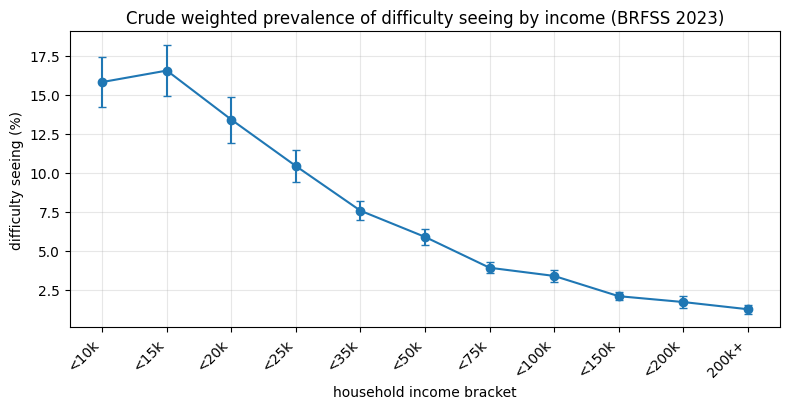

In [2]:
aux = info['aux']
def wmean_se(y, w):
    m = np.average(y, weights=w); n_eff = w.sum() ** 2 / (w ** 2).sum()
    return m, np.sqrt(m * (1 - m) / n_eff)
log_lo = rec.log_lo[rec.kind == 'bracket']
lows = {code: (np.log(lo) if lo > 0 else -np.inf) for code, (lo, hi) in rc.INCOME_BRACKETS_USD.items()}
inv = {round(v, 6): code for code, v in lows.items()}
br = aux[aux['kind'] == 'bracket'].copy()
br['code'] = [inv.get(round(v, 6), np.nan) for v in log_lo]
rows = []
for code, (lo, hi) in rc.INCOME_BRACKETS_USD.items():
    sub = br[br['code'] == code]
    if len(sub) == 0:
        continue
    m, se = wmean_se(sub['outcome'].to_numpy(), sub['w'].to_numpy())
    label = f"<{hi/1000:.0f}k" if np.isfinite(hi) else "200k+"
    rows.append((code, label, 100 * m, 100 * 1.96 * se))
grad = pd.DataFrame(rows, columns=['code', 'bracket', 'pct', 'ci95'])
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.errorbar(grad['code'], grad['pct'], yerr=grad['ci95'], marker='o', capsize=3, lw=1.5)
ax.set_xticks(grad['code']); ax.set_xticklabels(grad['bracket'], rotation=45, ha='right')
ax.set_xlabel('household income bracket'); ax.set_ylabel('difficulty seeing (%)')
ax.set_title('Crude weighted prevalence of difficulty seeing by income (BRFSS 2023)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Refused vs don't-know by group — the same two-mechanism signature?

The income missingness is the same item, so this panel should mirror notebook 02:
refused and don't-know trace different demographic patterns.

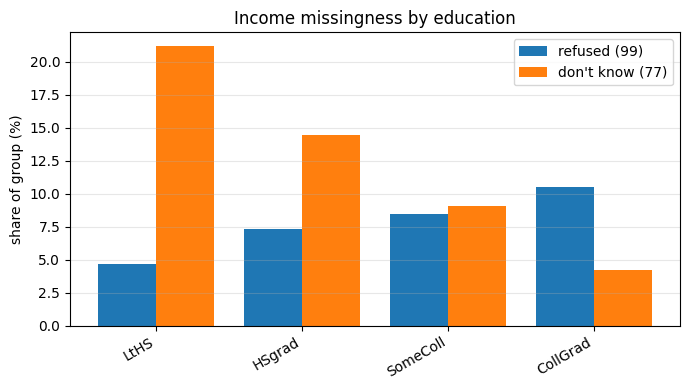

In [3]:
def shares_by(col, order):
    out = {}
    for key, sub in aux.groupby(col):
        w = sub['w'].to_numpy(); tot = w.sum()
        out[key] = {'refused': 100 * w[sub['kind'].to_numpy() == 'refused'].sum() / tot,
                    'dk': 100 * w[sub['kind'].to_numpy() == 'dk'].sum() / tot}
    res = pd.DataFrame(out).T
    return res.reindex([o for o in order if o in res.index])
fig, ax = plt.subplots(figsize=(7, 4))
s = shares_by('educ', ['LtHS', 'HSgrad', 'SomeColl', 'CollGrad'])
x = np.arange(len(s))
ax.bar(x - 0.2, s['refused'], 0.4, label='refused (99)')
ax.bar(x + 0.2, s['dk'], 0.4, label="don't know (77)")
ax.set_xticks(x); ax.set_xticklabels(s.index, rotation=30, ha='right')
ax.set_ylabel('share of group (%)'); ax.set_title('Income missingness by education')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

## A → B → C for difficulty seeing

In [4]:
t0 = time.time()
results = an.fit_all(rec, K=K)
rA, rB, rC = results
table, lin = an.abc_table(rec, strata, results, K)
print(f'fit + linearized CIs in {time.time()-t0:.1f}s')
table.to_csv(os.path.join(DERIVED, 'brfss_income_ABC_table_vision.csv'), index=False)
table

fit + linearized CIs in 40.4s


,model,OR per doubling,95% CI low,95% CI high,log-OR/doubling,lin SE,n used
0,A. midpoint + listwise,0.7553,0.7268,0.7848,-0.2807,0.0196,338342
1,B. grouped + listwise,0.7277,0.6966,0.7601,-0.3179,0.0223,338342
2,C. grouped + two-mech (γ=0),0.7273,0.6961,0.7599,-0.3184,0.0223,409359


In [5]:
# bootstrap confirmation (warm-started; the FMD notebook already validated that the
# linearized and bootstrap SEs agree on this same machinery)
B_BOOT = 30
t0 = time.time()
boot = an.bootstrap_confirm(rec, strata, results, B=B_BOOT, K_boot=24, seed=2023)
print(f'bootstrap ({B_BOOT} reps) in {(time.time()-t0)/60:.1f} min')
for k in 'ABC':
    print(f'  {k}: boot SE={boot[k].se:.4f} vs linearized SE={lin[k].se:.4f}')

bootstrap (30 reps) in 11.9 min
  A: boot SE=0.0225 vs linearized SE=0.0196
  B: boot SE=0.0253 vs linearized SE=0.0223
  C: boot SE=0.0256 vs linearized SE=0.0223


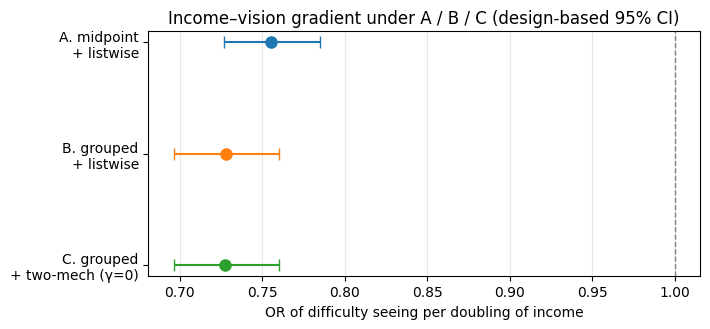

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
ys = [2, 1, 0]
labels = ['A. midpoint\n+ listwise', 'B. grouped\n+ listwise', 'C. grouped\n+ two-mech (γ=0)']
for y, key, res in zip(ys, 'ABC', [rA, rB, rC]):
    orp = np.exp(res.log_or_per_doubling)
    lo, hi = np.exp(lin[key].lo), np.exp(lin[key].hi)
    ax.errorbar([orp], [y], xerr=[[orp - lo], [hi - orp]], fmt='o', capsize=4, ms=8)
ax.axvline(1.0, color='gray', ls='--', lw=1)
ax.set_yticks(ys); ax.set_yticklabels(labels)
ax.set_xlabel('OR of difficulty seeing per doubling of income')
ax.set_title('Income–vision gradient under A / B / C (design-based 95% CI)')
ax.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

## Refusal-MNAR sensitivity sweep

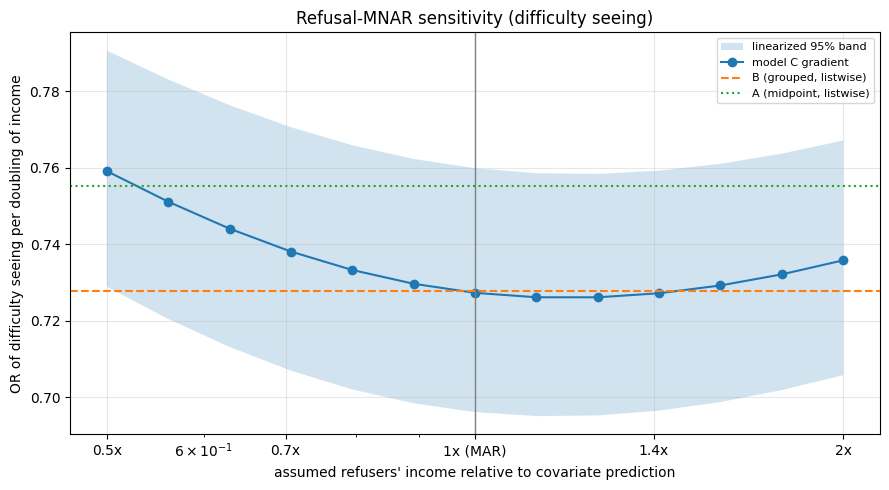

In [7]:
income = rB.income
deltas = np.linspace(np.log(0.5), np.log(2.0), 13)
sweep = an.mnar_sweep(rec, strata, income, K, deltas)
sweep.to_csv(os.path.join(DERIVED, 'brfss_income_mnar_sweep_vision.csv'), index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(sweep['income_ratio'], sweep['or_lo'], sweep['or_hi'], alpha=0.2,
                label='linearized 95% band')
ax.plot(sweep['income_ratio'], sweep['or'], '-o', label='model C gradient')
ax.axhline(rB.or_per_doubling, color='C1', ls='--', label='B (grouped, listwise)')
ax.axhline(rA.or_per_doubling, color='C2', ls=':', label='A (midpoint, listwise)')
ax.axvline(1.0, color='gray', lw=1)
ax.set_xscale('log'); ax.set_xticks([0.5, 0.7, 1.0, 1.4, 2.0])
ax.set_xticklabels(['0.5x', '0.7x', '1x (MAR)', '1.4x', '2x'])
ax.set_xlabel("assumed refusers' income relative to covariate prediction")
ax.set_ylabel('OR of difficulty seeing per doubling of income')
ax.set_title('Refusal-MNAR sensitivity (difficulty seeing)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Same general pattern? — vision vs frequent mental distress

Side-by-side with the FMD results from notebooks 03–04.

In [8]:
fmd_tab = pd.read_csv(os.path.join(DERIVED, 'brfss_income_ABC_table.csv'))
vis_tab = table
cmp = pd.DataFrame({
    'model': ['A. midpoint', 'B. grouped', 'C. two-mech (γ=0)'],
    'FMD OR/doubling': fmd_tab['OR per doubling'].values,
    'Vision OR/doubling': vis_tab['OR per doubling'].values,
})
print(cmp.to_string(index=False))

def shift(t):
    a, b, c = t['OR per doubling'].values
    return 100 * (b - a) / a, 100 * (c - b) / b
fa, fc = shift(fmd_tab); va, vc = shift(vis_tab)
print(f"\nA->B shift:  FMD {fa:+.1f}%   vision {va:+.1f}%")
print(f"B->C shift:  FMD {fc:+.1f}%   vision {vc:+.1f}%")
fmd_sweep = pd.read_csv(os.path.join(DERIVED, 'brfss_income_mnar_sweep.csv'))
print(f"\nMNAR sweep span (0.5x-2x refuser income):")
print(f"  FMD    OR {fmd_sweep['or'].min():.3f}-{fmd_sweep['or'].max():.3f}")
print(f"  vision OR {sweep['or'].min():.3f}-{sweep['or'].max():.3f}")

            model  FMD OR/doubling  Vision OR/doubling
      A. midpoint           0.8526              0.7553
       B. grouped           0.8364              0.7277
C. two-mech (γ=0)           0.8369              0.7273

A->B shift:  FMD -1.9%   vision -3.7%
B->C shift:  FMD +0.1%   vision -0.1%

MNAR sweep span (0.5x-2x refuser income):
  FMD    OR 0.827-0.868
  vision OR 0.726-0.759


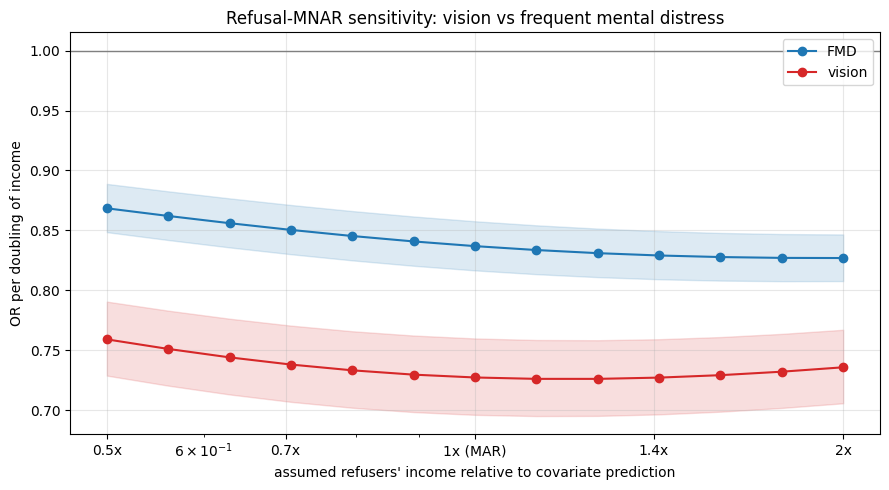

In [9]:
# overlay both sensitivity curves on a shared axis
fig, ax = plt.subplots(figsize=(9, 5))
for s, lab, c in [(fmd_sweep, 'FMD', 'C0'), (sweep, 'vision', 'C3')]:
    ax.fill_between(s['income_ratio'], s['or_lo'], s['or_hi'], alpha=0.15, color=c)
    ax.plot(s['income_ratio'], s['or'], '-o', color=c, label=lab)
ax.axhline(1.0, color='gray', lw=1)
ax.set_xscale('log'); ax.set_xticks([0.5, 0.7, 1.0, 1.4, 2.0])
ax.set_xticklabels(['0.5x', '0.7x', '1x (MAR)', '1.4x', '2x'])
ax.set_xlabel("assumed refusers' income relative to covariate prediction")
ax.set_ylabel('OR per doubling of income')
ax.set_title('Refusal-MNAR sensitivity: vision vs frequent mental distress')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()